## Natural Language Processing

#### Importing The Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Importing The Dataset

In [2]:
covid_train_data = pd.read_csv("Corona_NLP_train.csv", encoding="latin-1")
covid_train_data

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative
...,...,...,...,...,...,...
41152,44951,89903,"Wellington City, New Zealand",14-04-2020,Airline pilots offering to stock supermarket s...,Neutral
41153,44952,89904,NaN,14-04-2020,Response to complaint not provided citing COVI...,Extremely Negative
41154,44953,89905,NaN,14-04-2020,You know itÂs getting tough when @KameronWild...,Positive
41155,44954,89906,NaN,14-04-2020,Is it wrong that the smell of hand sanitizer i...,Neutral


In [3]:
covid_test_data = pd.read_csv("Corona_NLP_test.csv")
covid_test_data

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,1,44953,NYC,02-03-2020,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative
1,2,44954,"Seattle, WA",02-03-2020,When I couldn't find hand sanitizer at Fred Me...,Positive
2,3,44955,NaN,02-03-2020,Find out how you can protect yourself and love...,Extremely Positive
3,4,44956,Chicagoland,02-03-2020,#Panic buying hits #NewYork City as anxious sh...,Negative
4,5,44957,"Melbourne, Victoria",03-03-2020,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral
...,...,...,...,...,...,...
3793,3794,48746,Israel ??,16-03-2020,Meanwhile In A Supermarket in Israel -- People...,Positive
3794,3795,48747,"Farmington, NM",16-03-2020,Did you panic buy a lot of non-perishable item...,Negative
3795,3796,48748,"Haverford, PA",16-03-2020,Asst Prof of Economics @cconces was on @NBCPhi...,Neutral
3796,3797,48749,NaN,16-03-2020,Gov need to do somethings instead of biar je r...,Extremely Negative


In [4]:
## Basic Information of TRAIN DATA
covid_train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserName       41157 non-null  int64 
 1   ScreenName     41157 non-null  int64 
 2   Location       32567 non-null  object
 3   TweetAt        41157 non-null  object
 4   OriginalTweet  41157 non-null  object
 5   Sentiment      41157 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.9+ MB


In [5]:
## Basic Information of TEST DATA
covid_test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserName       3798 non-null   int64 
 1   ScreenName     3798 non-null   int64 
 2   Location       2964 non-null   object
 3   TweetAt        3798 non-null   object
 4   OriginalTweet  3798 non-null   object
 5   Sentiment      3798 non-null   object
dtypes: int64(2), object(4)
memory usage: 178.2+ KB


## Exploratory Data Analysis

### Checking Location wise Tweets

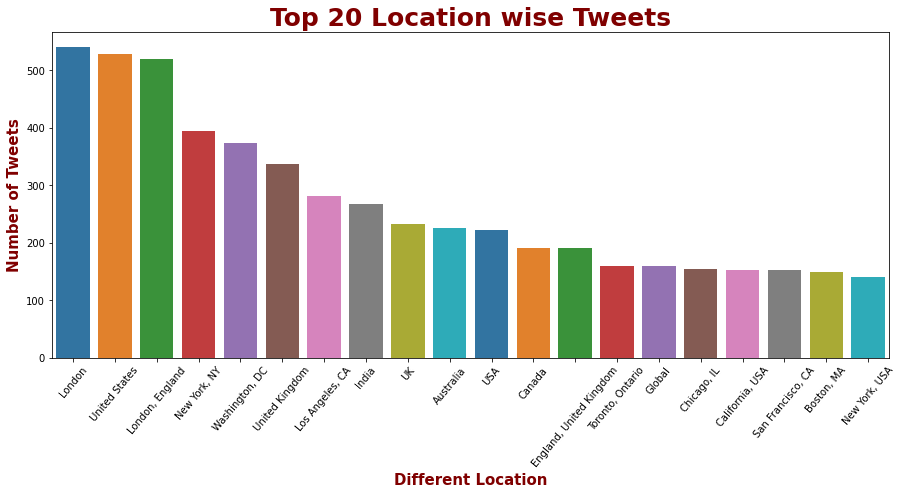


 --Value Counts-- 

London                          540
United States                   528
London, England                 520
New York, NY                    395
Washington, DC                  373
                               ... 
Staffordshire Moorlands           1
Kithchener ON                     1
Tulsa, Ok                         1
Watford, South Oxhey, Bushey      1
i love you so much || he/him      1
Name: Location, Length: 12220, dtype: int64


In [6]:
plt.figure(figsize=(15,6))
plt.title("Top 20 Location wise Tweets", fontsize=25, fontweight="bold", color="Maroon")

location = sns.countplot(x="Location", data=covid_train_data, 
                         order=covid_train_data["Location"].value_counts().index[:20], 
                         palette="tab10")

plt.xlabel("Different Location", fontsize=15, fontweight="bold", color="Maroon")
plt.ylabel("Number of Tweets", fontsize=15, fontweight="bold", color="Maroon")
plt.xticks(rotation=50)
plt.show()

print('\n --Value Counts-- \n')
print(covid_train_data['Location'].value_counts())

### Checking Sentiment Of Tweets

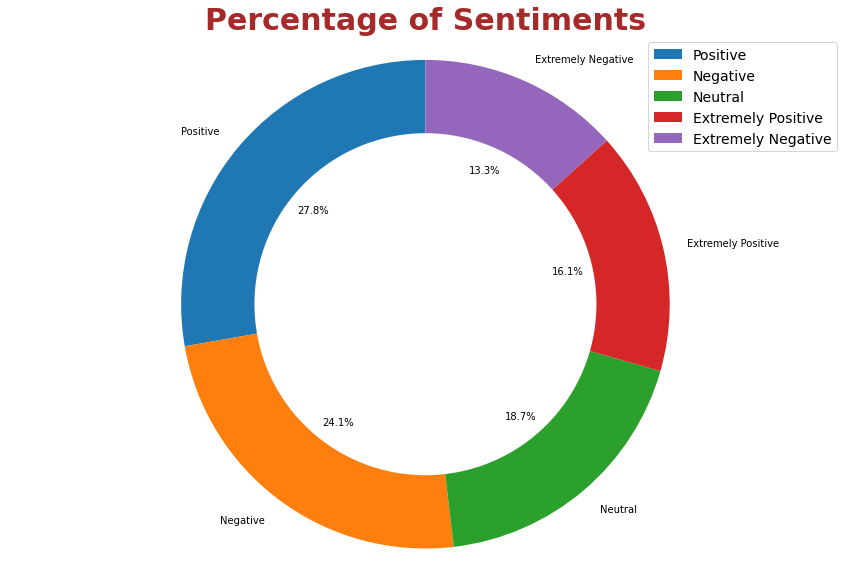


 --Value Counts-- 

Positive              11422
Negative               9917
Neutral                7713
Extremely Positive     6624
Extremely Negative     5481
Name: Sentiment, dtype: int64


In [7]:
## Making A Donut-Chart to see percentage of Sentiments

sentiment = covid_train_data['Sentiment'].value_counts()

plt.figure(figsize=(15, 10))
plt.pie(sentiment.values, labels=sentiment.index, startangle=90, autopct='%1.1f%%')

centre_circle = plt.Circle((0, 0), 0.7, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Percentage of Sentiments", fontsize=30, fontweight='bold', color='brown')
plt.axis('equal')
plt.legend(prop={'size': 14})
plt.show()

print('\n --Value Counts-- \n')
print(covid_train_data['Sentiment'].value_counts())

### Checking Date Wise Number Of Tweets

In [8]:
date_of_tweet = covid_train_data.groupby(["TweetAt"]).size().reset_index(name="Number Of Tweets")
date_of_tweet

,TweetAt,Number Of Tweets
0,01-04-2020,630
1,02-04-2020,954
2,03-04-2020,810
3,04-04-2020,767
4,05-04-2020,1131
5,06-04-2020,1742
6,07-04-2020,1843
7,08-04-2020,1881
8,09-04-2020,1471
9,10-04-2020,1005


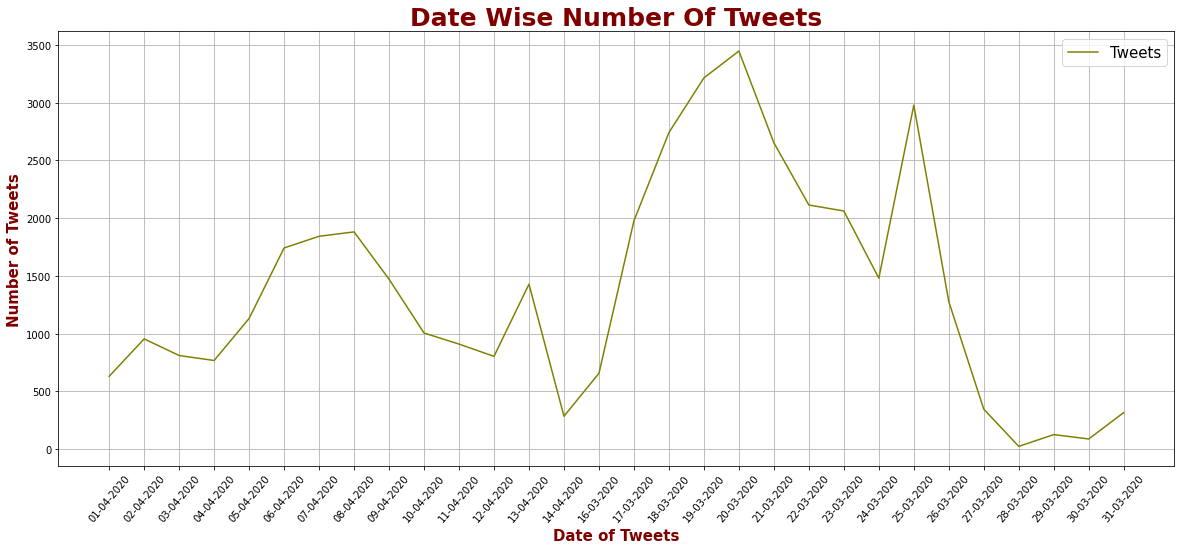

In [9]:
## Making VG Diagram

x = date_of_tweet["TweetAt"]
y = date_of_tweet["Number Of Tweets"]

plt.figure(figsize=(20,8))
plt.grid()
plt.title("Date Wise Number Of Tweets", fontsize=25, fontweight="bold", color="Maroon")

plt.plot(x,y, label="Tweets", color="olive")

plt.xlabel("Date of Tweets", fontsize=15, fontweight="bold", color="Maroon")
plt.ylabel("Number of Tweets", fontsize=15, fontweight="bold", color="Maroon")
plt.xticks(rotation=50)
plt.legend(prop={'size': 15})
plt.show()

### Checking Sentiments On Respective Tweets

##### Most 50 Sentiments On Respective Tweets

In [10]:
top50 = covid_train_data[0:50]
top50

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative
5,3804,48756,"ÃT: 36.319708,-82.363649",16-03-2020,As news of the regionÂs first confirmed COVID...,Positive
6,3805,48757,"35.926541,-78.753267",16-03-2020,Cashier at grocery store was sharing his insig...,Positive
7,3806,48758,Austria,16-03-2020,Was at the supermarket today. Didn't buy toile...,Neutral
8,3807,48759,"Atlanta, GA USA",16-03-2020,Due to COVID-19 our retail store and classroom...,Positive
9,3808,48760,"BHAVNAGAR,GUJRAT",16-03-2020,"For corona prevention,we should stop to buy th...",Negative


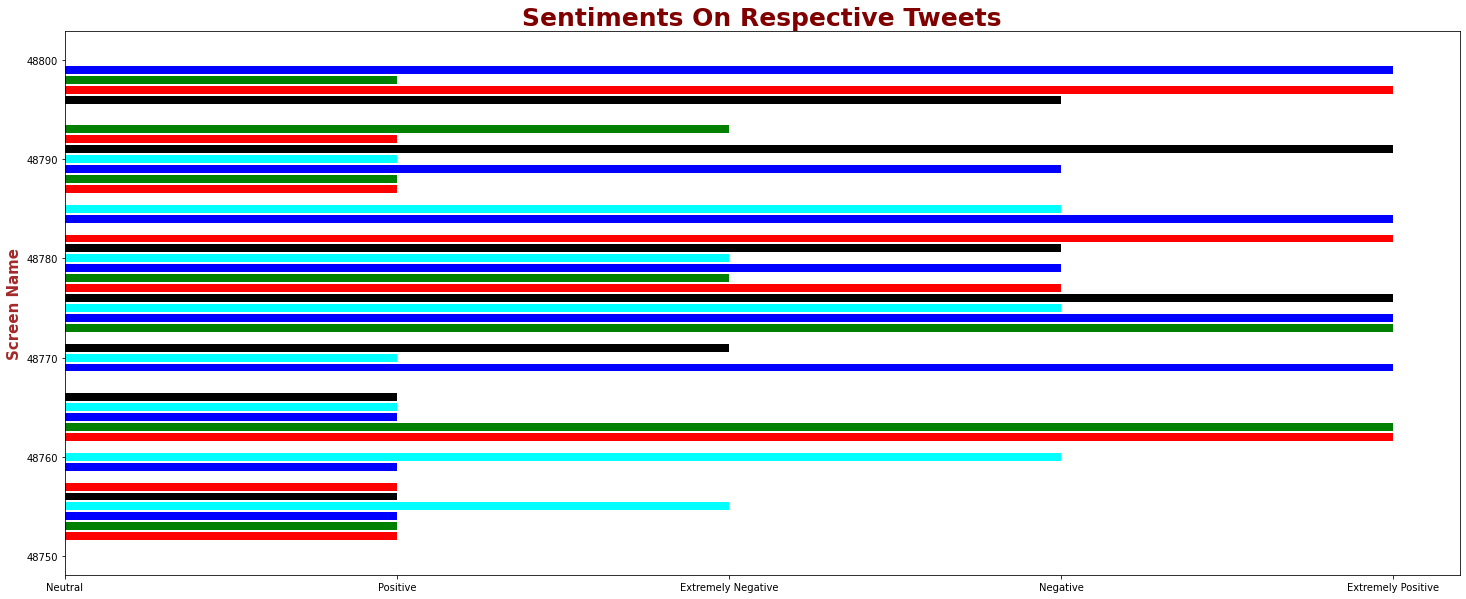

In [11]:
## Making Bar(horizontal) Chart to see Sentiments On Respective Tweets

plt.figure(figsize=(25,10))
plt.title("Sentiments On Respective Tweets", fontsize=25, fontweight="bold", color="Maroon")

plt.barh(top50["ScreenName"], top50["Sentiment"], 
         color=['black', 'red', 'green', 'blue', 'cyan'])

plt.ylabel("Screen Name", fontsize=15, fontweight='bold', color='brown')
plt.show()

### Checking On which date the maximum tweets are tweeted.

In [12]:
tweets = covid_train_data.groupby("TweetAt")[["OriginalTweet"]].count()
tweets

,OriginalTweet
TweetAt,
01-04-2020,630
02-04-2020,954
03-04-2020,810
04-04-2020,767
05-04-2020,1131
06-04-2020,1742
07-04-2020,1843
08-04-2020,1881
09-04-2020,1471


#### Top 5 Date: The maximum tweets are tweeted.

In [13]:
pd.options.display.max_colwidth = 100
tweets.sort_values(by="OriginalTweet", ascending=False).head(5)

,OriginalTweet
TweetAt,
20-03-2020,3448
19-03-2020,3215
25-03-2020,2979
18-03-2020,2742
21-03-2020,2653


#### Top 5 Date: The minimum tweets are tweeted.

In [14]:
pd.options.display.max_colwidth = 100
tweets.sort_values(by="OriginalTweet", ascending=False).tail(5)

,OriginalTweet
TweetAt,
31-03-2020,316
14-04-2020,284
29-03-2020,125
30-03-2020,87
28-03-2020,23


## Data Preprocessing

### Selecting Features

In [15]:
## selecting only relevant variables that are "OriginalTweet" and "Sentiment" columns

train_data = covid_train_data[["OriginalTweet", "Sentiment"]]
test_data = covid_test_data[["OriginalTweet", "Sentiment"]]

In [16]:
train_data.head()

,OriginalTweet,Sentiment
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/iFz9FAn2Pa and https://t.co/xX6ghGFzCC and https://...,Neutral
1,advice Talk to your neighbours family to exchange phone numbers create contact list with phone n...,Positive
2,"Coronavirus Australia: Woolworths to give elderly, disabled dedicated shopping hours amid COVID-...",Positive
3,"My food stock is not the only one which is empty...\r\r\n\r\r\nPLEASE, don't panic, THERE WILL B...",Positive
4,"Me, ready to go at supermarket during the #COVID19 outbreak.\r\r\n\r\r\nNot because I'm paranoid...",Extremely Negative


In [17]:
test_data.head()

,OriginalTweet,Sentiment
0,"TRENDING: New Yorkers encounter empty supermarket shelves (pictured, Wegmans in Brooklyn), sold-...",Extremely Negative
1,"When I couldn't find hand sanitizer at Fred Meyer, I turned to #Amazon. But $114.97 for a 2 pack...",Positive
2,Find out how you can protect yourself and loved ones from #coronavirus. ?,Extremely Positive
3,#Panic buying hits #NewYork City as anxious shoppers stock up on food&amp;medical supplies after...,Negative
4,#toiletpaper #dunnypaper #coronavirus #coronavirusaustralia #CoronaVirusUpdate #Covid_19 #9News ...,Neutral


#### Checking Missing Values

In [18]:
train_data.isnull().sum()

OriginalTweet    0
Sentiment        0
dtype: int64

In [19]:
test_data.isnull().sum()

OriginalTweet    0
Sentiment        0
dtype: int64

        ♦  There are no missing values in both train_data and test_data.

##### Encoding target variables

In [20]:
encode = {"Extremely Negative":0, "Negative":0, "Neutral":1, "Extremely Positive":2, "Positive":2}

train_data["EncodedSentiment"] = train_data["Sentiment"].map(lambda x:encode[x])
test_data["EncodedSentiment"] = test_data["Sentiment"].map(lambda x:encode[x])

In [21]:
train_data.head()

,OriginalTweet,Sentiment,EncodedSentiment
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/iFz9FAn2Pa and https://t.co/xX6ghGFzCC and https://...,Neutral,1
1,advice Talk to your neighbours family to exchange phone numbers create contact list with phone n...,Positive,2
2,"Coronavirus Australia: Woolworths to give elderly, disabled dedicated shopping hours amid COVID-...",Positive,2
3,"My food stock is not the only one which is empty...\r\r\n\r\r\nPLEASE, don't panic, THERE WILL B...",Positive,2
4,"Me, ready to go at supermarket during the #COVID19 outbreak.\r\r\n\r\r\nNot because I'm paranoid...",Extremely Negative,0


In [22]:
test_data.head()

,OriginalTweet,Sentiment,EncodedSentiment
0,"TRENDING: New Yorkers encounter empty supermarket shelves (pictured, Wegmans in Brooklyn), sold-...",Extremely Negative,0
1,"When I couldn't find hand sanitizer at Fred Meyer, I turned to #Amazon. But $114.97 for a 2 pack...",Positive,2
2,Find out how you can protect yourself and loved ones from #coronavirus. ?,Extremely Positive,2
3,#Panic buying hits #NewYork City as anxious shoppers stock up on food&amp;medical supplies after...,Negative,0
4,#toiletpaper #dunnypaper #coronavirus #coronavirusaustralia #CoronaVirusUpdate #Covid_19 #9News ...,Neutral,1


   ####   ♦ Sentiments have been encoded:
                                    
                                    • Nagative            -> 0                
                                    • Extremely Negative  -> 0
                    
                                    • Neutral             -> 1
                        
                                    • Positive            -> 2
                                    • Extremely Positive  -> 2

## Text Cleaning

#### Importing Libraries for TEXT Cleaning

In [23]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

In [24]:
all_stopwords = stopwords.words("english")
all_stopwords.remove("not")

def preprocessor(data):
    corpus = []
    for i in range(len(data)):
        # Remove URLs
        tweet_1 = re.sub(r"http\S+", " ", data["OriginalTweet"][i])
        # Remove html tags
        tweet_2 = re.sub(r"<.*?>", " ", tweet_1)
        # Remove Digits
        tweet_3 = re.sub(r"\d+", " ", tweet_2)
        # Remove hashtags
        tweet_4 = re.sub(r"#\w+", " ", tweet_3)
        review = re.sub("[^a-zA-Z]", " ", tweet_4)
        review = review.lower()
        review = review.split()
        ps = PorterStemmer()
        review = [ps.stem(word) for word in review if not word in all_stopwords]
        review = " ".join(review)
        corpus.append(review)
    return corpus

##### Now, Transforming the OriginalTweet

In [25]:
corpus_train = preprocessor(train_data)
corpus_test = preprocessor(test_data)

In [26]:
# Displaying the first 5 rows in corpus_train
corpus_train[0:5]

['menyrbi phil gahan chrisitv',
 'advic talk neighbour famili exchang phone number creat contact list phone number neighbour school employ chemist gp set onlin shop account poss adequ suppli regular med not order',
 'coronaviru australia woolworth give elderli disabl dedic shop hour amid covid outbreak',
 'food stock not one empti pleas panic enough food everyon not take need stay calm stay safe franc',
 'readi go supermarket outbreak not paranoid food stock litterali empti seriou thing pleas panic caus shortag']

In [27]:
# Displaying the first 5 rows in corpus_test
corpus_test[0:5]

['trend new yorker encount empti supermarket shelv pictur wegman brooklyn sold onlin grocer foodkick maxdeliveri fear shopper stock',
 'find hand sanit fred meyer turn pack purel check concern drive price',
 'find protect love one',
 'buy hit citi anxiou shopper stock food amp medic suppli worker becom st confirm patient stage event',
 'news newsmelb one week everyon buy babi milk powder next everyon buy toilet paper']

### Creating The Bag of Words Model

In [28]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

# splitting training and test data
X_train = cv.fit_transform(corpus_train).toarray()
y_train = train_data["EncodedSentiment"]
X_test = cv.transform(corpus_test).toarray()
y_test = test_data["EncodedSentiment"]

In [29]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(41157, 31750)
(41157,)
(3798, 31750)
(3798,)


### Building Gaussian Naive Bayes Model

In [30]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()

# fitting training data
gnb.fit(X_train, y_train)

GaussianNB()

### Predicting the Test set results

In [31]:
y_pred = gnb.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.values.reshape(len(y_test),1)),1))

[[1 0]
 [1 2]
 [1 2]
 ...
 [2 1]
 [1 0]
 [1 2]]


### Model Evaluation

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#### Model Accuracy Score

In [33]:
model_score = accuracy_score(y_test, y_pred)
print("Model Accuracy Score :- ", model_score)

Model Accuracy Score :-  0.3267509215376514


#### Making The Confusion Matrix

In [34]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[603 870 160]
 [117 456  46]
 [503 861 182]]


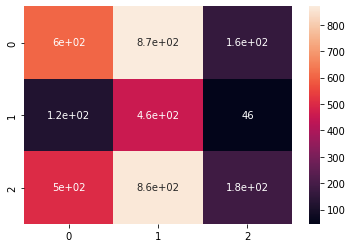

In [35]:
sns.heatmap(cm, annot=True)
plt.show()

#### Classification Report Of Model

In [36]:
model_report = classification_report(y_test, y_pred)
print(model_report)

              precision    recall  f1-score   support

           0       0.49      0.37      0.42      1633
           1       0.21      0.74      0.33       619
           2       0.47      0.12      0.19      1546

    accuracy                           0.33      3798
   macro avg       0.39      0.41      0.31      3798
weighted avg       0.44      0.33      0.31      3798

